In [1]:
import numpy as np
import os
import pandas as pd

In [2]:
working_dir = 'Data'
working_dir_combined = 'Data_combined'

In [3]:
import torch
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import numpy as np

class CustomDataset(Dataset):
    def __init__(self, path_airs, path_indices, path_ground):
        """
        Args:
            data_airs (np.array): Array of shape (673, 187, 282, 32).
            data_indices (np.array): Array of indices corresponding to the rows in df_labels.
            df_labels (pd.DataFrame): DataFrame of shape (673, 284) containing the labels.
        """
        self.data_airs = torch.tensor( np.load(os.path.join(working_dir_combined, path_airs), allow_pickle=True))  # Convert the data to a tensor
        self.data_indices = torch.tensor(np.load(os.path.join(working_dir_combined, path_indices), allow_pickle=True)).long()  # Convert indices to tensor
        self.df_labels = pd.read_csv(path_ground)  # Keep df_labels as a pandas DataFrame

    def __len__(self):
        # Return the total number of samples
        return len(self.data_indices)

    def __getitem__(self, idx):
        # Get the index from data_indices
        index = self.data_indices[idx].item()  # Convert tensor to Python scalar
        
        # Select the data_airs corresponding to the index
        data_sample = self.data_airs[idx]
        
        # Select the corresponding label row where the first column matches the index
        label_row = self.df_labels[self.df_labels.iloc[:, 0] == index].iloc[0].values[1:]  # Exclude the first column (index)

        # Convert label_row to a tensor
        label = torch.tensor(label_row).float()

        return data_sample, label

# Example usage
# Assuming data_airs is the (673, 187, 282, 32) numpy array, data_indices is the indices array,
# and df_labels is the pandas DataFrame (673, 284), with the first column being the index column

# Create the dataset
path_ground =  'train_labels.csv'
path_indices = 'indices_trim.npy'
path_airs = 'data_train_airs.npy'
custom_dataset = CustomDataset(path_airs, path_indices, path_ground)

# Create a DataLoader to iterate over the dataset (optional)
dataloader = DataLoader(custom_dataset, batch_size=32, shuffle=True)

# Iterate through the dataset
for batch_data, batch_labels in dataloader:
    print("Batch Data Shape:", batch_data.shape)  # (batch_size, 187, 282, 32)
    print("Batch Labels Shape:", batch_labels.shape)  # (batch_size, 283) -> since we exclude the first index column
    break


Batch Data Shape: torch.Size([32, 187, 282, 32])
Batch Labels Shape: torch.Size([32, 283])


In [4]:
import matplotlib.pyplot as plt 

print('Shape of the training datasset: \t')
print('\n For AIRS-CH0:', batch_data.shape)
print('\n Labels:', batch_labels.shape)

Shape of the training datasset: 	

 For AIRS-CH0: torch.Size([32, 187, 282, 32])

 Labels: torch.Size([32, 283])


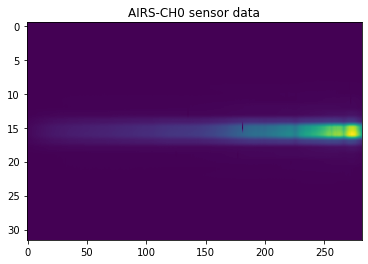

In [5]:
plt.imshow(batch_data[-1,50,:,:].T, aspect = 'auto')
plt.title("AIRS-CH0 sensor data")
plt.show()

/var/folders/dp/l6p51q511nbb1spwhbnzhnkc0000gs/T/ipykernel_9587/2867722626.py:1: UserWarning: The use of `x.T` on tensors of dimension other than 2 to reverse their shape is deprecated and it will throw an error in a future release. Consider `x.mT` to transpose batches of matrices or `x.permute(*torch.arange(x.ndim - 1, -1, -1))` to reverse the dimensions of a tensor. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/TensorShape.cpp:3641.)
  plt.plot(batch_labels[-1].T)


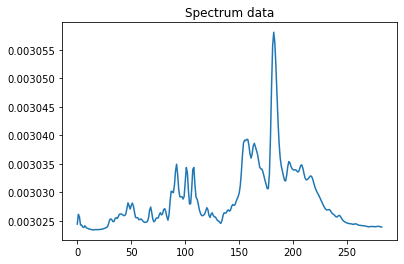

In [6]:
plt.plot(batch_labels[-1].T)
plt.title("Spectrum data")
plt.show()

In [7]:
# ! pip install git+https://github.com/openai/whisper.git


In [8]:
try:
    import tensorflow  # required in Colab to avoid protobuf compatibility issues
except ImportError:
    pass

import whisper
import torchaudio
import torch

from tqdm.notebook import tqdm
from whisper.model import AudioEncoder
from whisper import ModelDimensions
DEVICE = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
DEVICE

device(type='mps')

In [9]:
whisper_model_type = 'tiny' # Specify the whisper model type here

In [10]:
# Load model dimensions
default = os.path.join(os.path.expanduser("~"), ".cache")
download_root = os.path.join(os.getenv("XDG_CACHE_HOME", default), "whisper")
checkpoint_file = whisper._download(whisper._MODELS[whisper_model_type], download_root, in_memory=False)

alignment_heads = whisper._ALIGNMENT_HEADS["base"]

with (
    open(checkpoint_file, "rb")
) as fp:
    checkpoint = torch.load(fp, map_location=DEVICE)
del checkpoint_file

dims = ModelDimensions(**checkpoint["dims"])
dims

ModelDimensions(n_mels=80, n_audio_ctx=1500, n_audio_state=384, n_audio_head=6, n_audio_layer=4, n_vocab=51865, n_text_ctx=448, n_text_state=384, n_text_head=6, n_text_layer=4)

In [11]:
from torch import Tensor, nn
import torch.nn.functional as F

In [12]:
# ! pip install jiwer

In [13]:
from whisper.model import ResidualAttentionBlock,Iterable, LayerNorm, Optional, Dict

In [14]:
class AudioEncoder(nn.Module):
    def __init__(
        self, n_mels: int, n_ctx: int, n_state: int, n_head: int, n_layer: int
    ):
        super().__init__()
        self.conv1 = whisper.model.Conv1d(n_mels, n_state, kernel_size=3, padding=1)
        self.conv2 = whisper.model.Conv1d(n_state, n_state, kernel_size=3, stride=2, padding=1)
        self.register_buffer("positional_embedding", 0*whisper.model.sinusoids(n_ctx, n_state))

        self.blocks: Iterable[ResidualAttentionBlock] = nn.ModuleList(
            [whisper.model.ResidualAttentionBlock(n_state, n_head) for _ in range(n_layer)]
        )
        self.ln_post = whisper.model.LayerNorm(n_state)

    def forward(self, x: Tensor):
        """
        x : torch.Tensor, shape = (batch_size, n_mels, n_ctx)
            the mel spectrogram of the audio
        """
        x = F.gelu(self.conv1(x))
        
        x = F.gelu(self.conv2(x))
        
        x = x.permute(0, 2, 1)
        
        assert x.shape[1:] == self.positional_embedding.shape, "incorrect audio shape"
        x = (x + self.positional_embedding).to(x.dtype)

        for block in self.blocks:
            x = block(x)

        x = self.ln_post(x)
        return x

In [15]:
from math import *

In [16]:
# # Conv1 layer's input dimension and convolution parameters
# L_in_conv1 = 187
# padding_conv1 = encoder.conv1.padding[0]
# stride_conv1 = encoder.conv1.stride[0]
# dilation_conv1 = encoder.conv1.dilation[0]
# kernel_size_conv1 = encoder.conv1.kernel_size[0]
# print("For Conv1 layer, Padding: {}, Stride: {}, Dilation: {}, Kernel Size: {}".format(padding_conv1, stride_conv1, dilation_conv1, kernel_size_conv1))

In [17]:
# # Conv1 layer's output dimension
# L_out_conv1 = floor((L_in_conv1 + 2 * padding_conv1 - dilation_conv1 * (kernel_size_conv1 - 1) - 1)/stride_conv1 + 1)
# L_out_conv1

In [18]:
# # Conv2 layer's input dimension and convolution parameters
# L_in_conv2 = L_out_conv1
# padding_conv2 = encoder.conv2.padding[0]
# stride_conv2 = encoder.conv2.stride[0]
# dilation_conv2 = encoder.conv2.dilation[0]
# kernel_size_conv2 = encoder.conv2.kernel_size[0]
# print("For Conv2 layer, Padding: {}, Stride: {}, Dilation: {}, Kernel Size: {}".format(padding_conv2, stride_conv2, dilation_conv2, kernel_size_conv2))

In [19]:
# # Conv1 layer's output dimension
# L_out_conv2 = floor((L_in_conv2 + 2 * padding_conv2 - dilation_conv2 * (kernel_size_conv2 - 1) - 1)/stride_conv2 + 1)
# L_out_conv2

In [20]:
dims.n_mels = 9024
dims.n_audio_ctx = 94

In [21]:
# encoder = AudioEncoder(
#     dims.n_mels,
#     dims.n_audio_ctx,
#     dims.n_audio_state,
#     dims.n_audio_head,
#     dims.n_audio_layer,
# )

In [22]:
# light_curve_unshaped = batch_data.clone().detach()
# light_curve_reshaped = batch_data.reshape(32,187,-1) #data_train.mean(axis=(2,3))
# light_curve_reshaped = torch.tensor(light_curve_reshaped/light_curve_reshaped.mean(axis=(0,1,2)), dtype=torch.float)
# light_curve_reshaped = light_curve_reshaped.permute(0,2,1)
# light_curve_reshaped.shape


In [23]:
# Given groups=1, weight of size [384, 9024, 3], expected input[32, 282, 187] to have 9024 channels, but got 282 channels instead

In [24]:
# encoded_light_curve = encoder(light_curve_reshaped)

In [25]:
# plt.figure(figsize=(17,17))
# plt.imshow(encoded_light_curve[0,:,:].detach().numpy())
# plt.show()

In [26]:
class SpectralDecoder(nn.Module):
    def __init__(
        self, n_ctx: int, n_dimout: int, n_state: int, n_head: int, n_layer: int
    ):
        super().__init__()

        
        self.blocks: Iterable[ResidualAttentionBlock] = nn.ModuleList(
            [
                ResidualAttentionBlock(n_state, n_head, cross_attention=True)
                for _ in range(n_layer)
            ]
        )
        self.ln = LayerNorm(n_state)
        self.fc_out = nn.Linear(n_ctx*n_state, n_dimout)
        # mask = torch.empty(n_ctx, n_ctx).fill_(-np.inf).triu_(1)
        # self.register_buffer("mask", mask, persistent=False)

    def forward(self, x: Tensor, kv_cache: Optional[dict] = None):
        """
        x : torch.LongTensor, shape = (batch_size, <= n_ctx)
            the text tokens
        xa : torch.Tensor, shape = (batch_size, n_audio_ctx, n_audio_state)
            the encoded audio features to be attended on
        """
        # offset = next(iter(kv_cache.values())).shape[1] if kv_cache else 0
        # x = (
        #     self.token_embedding(x)
        #     + self.positional_embedding[offset : offset + x.shape[-1]]
        # )
        # x = x.to(xa.dtype)
        y = x.detach()
        
        for block in self.blocks:
            x = block(y, x, mask=None, kv_cache=kv_cache)

        x = self.ln(x)
        x = x.flatten(start_dim=1)
        x = self.fc_out(x)
        # x = torch.sigmoid(x)
        
        return x



In [27]:
dims

ModelDimensions(n_mels=9024, n_audio_ctx=94, n_audio_state=384, n_audio_head=6, n_audio_layer=4, n_vocab=51865, n_text_ctx=448, n_text_state=384, n_text_head=6, n_text_layer=4)

In [28]:
class SpectralTransformer(nn.Module):
    def __init__(self, dims: ModelDimensions):
        super().__init__()
        self.dims = dims
        self.encoder = AudioEncoder(
            self.dims.n_mels,
            self.dims.n_audio_ctx,
            self.dims.n_audio_state,
            self.dims.n_audio_head,
            self.dims.n_audio_layer,
        )
        self.decoder = SpectralDecoder(
            self.dims.n_audio_ctx,
            283,
            self.dims.n_text_state,
            self.dims.n_text_head,
            self.dims.n_text_layer,
        )


    def forward(
        self, x: torch.Tensor
    ):
        return self.decoder(self.encoder(x))


In [29]:
# dims.n_text_state = 283

In [30]:
# dims

In [31]:
specTrans = SpectralTransformer(dims=dims)

In [32]:
# light_curve_reshaped.shape

In [33]:
light_curve_unshaped = batch_data.clone().detach()
light_curve_reshaped = batch_data.reshape(32,187,-1) #data_train.mean(axis=(2,3))
light_curve_reshaped = torch.tensor(light_curve_reshaped/light_curve_reshaped.mean(axis=(0,1,2)), dtype=torch.float)
light_curve_reshaped = light_curve_reshaped.permute(0,2,1)
light_curve_reshaped.shape


In [34]:
# light_curve_reshaped.shape

In [35]:
output = specTrans(light_curve_reshaped.to('cpu'))

NameError: name 'light_curve_reshaped' is not defined

In [ ]:
plt.plot(output.cpu().detach().numpy()[-1])
plt.title('Plot of model output')
plt.show()

In [36]:
import scipy.stats

In [ ]:
# arr = [1,2,3,4,5]
# arr[:2]

In [ ]:
# import torch
# import torch.nn as nn

# class GLLLoss(nn.Module):
#     def __init__(self, naive_mean: float, naive_sigma: float, sigma_true: float):
#         super(GLLLoss, self).__init__()
#         self.naive_mean = naive_mean
#         self.naive_sigma = naive_sigma
#         self.sigma_true = sigma_true

#     def forward(self, y_true, y_output):

#         """
#         y_true: Ground truth spectra (from test set), shape: (batch_size, n_wavelengths)
#         y_pred_mean: Predicted spectra mean (from the model), shape: (batch_size, n_wavelengths)
#         y_pred_sigma: Predicted spectra sigma (variance), shape: (batch_size, n_wavelengths)

#         Returns:
#         GLL-based loss value for one batch
#         """
#         y_true = y_true.cpu().detach().numpy()
#         y_output = y_output.cpu().detach().numpy()
#         n_wavelengths = y_true.shape[1]
#         y_pred = y_output[:,:n_wavelengths] # Select wavelengths
#         sigma_pred = np.clip(y_output[:,n_wavelengths:], a_min=10**-15, a_max=None)

#         GLL_pred = np.sum(scipy.stats.norm.logpdf(y_true, loc=y_pred, scale=sigma_pred))
#         GLL_true = np.sum(scipy.stats.norm.logpdf(y_true, loc=y_true, scale=self.sigma_true * np.ones_like(y_true)))
#         GLL_mean = np.sum(scipy.stats.norm.logpdf(y_true, loc=self.naive_mean * np.ones_like(y_true), scale=self.naive_sigma * np.ones_like(y_true)))

#         submit_score = (GLL_pred - GLL_mean)/(GLL_true - GLL_mean)
#         return torch.log(torch.abs(torch.tensor(GLL_pred, requires_grad=True))), torch.tensor(1 - np.clip(submit_score, 0.0, 1.0), requires_grad=True)
#         # return torch.log(torch.abs(torch.tensor(GLL_pred, requires_grad=True))), float(np.clip(submit_score, 0.0, 1.0))


In [37]:
args = {}



# Training params
args['alpha_l2'] = 1e-4 # L2 regulariser
args['batch_size'] = 32
args['test_batch_size'] = 10

args['epochs'] = 50
args['start_epoch'] = 0


args['hidden_neurons'] = 64




# For optimizer
args['lr'] = 1e-3 # LR for B-SNN params
args['lr_decay'] = 1e-4

args['lr_threshold'] = 1e-2 # LR for B-SNN learnable thresholds
args['lr_th_decay'] = 1e-1    

args['momentum'] = 0.5 # Required for SGD optimiser
args['weight_decay'] = 1e-4 # Weight-decay for ADAM-W optimiser

# Set seed for RNG
args['seed-sklearn'] = 54 
args['torch-seed'] = 15462463436609368511

args['device'] =  torch.device('mps' if torch.backends.mps.is_available() else 'cpu')


In [38]:
# import torch
# import torch.nn as nn

# class GLLLoss(nn.Module):
#     def __init__(self, naive_mean: float, naive_sigma: float, sigma_true: float):
#         super(GLLLoss, self).__init__()
#         self.naive_mean = torch.tensor(naive_mean, dtype=torch.float32, device=args["device"])
#         self.naive_sigma =torch.tensor( naive_sigma, dtype=torch.float32, device=args["device"])
#         self.sigma_true =torch.tensor( sigma_true, dtype=torch.float32, device=args["device"]) 

#     def forward(self, y_true, y_output):

#         """
#         y_true: Ground truth spectra (from test set), shape: (batch_size, n_wavelengths)
#         y_pred_mean: Predicted spectra mean (from the model), shape: (batch_size, n_wavelengths)
#         y_pred_sigma: Predicted spectra sigma (variance), shape: (batch_size, n_wavelengths)

#         Returns:
#         GLL-based loss value for one batch
#         """
#         n_wavelengths = y_true.shape[1]
#         y_pred = y_output[:,:n_wavelengths] # Select wavelengths
#         sigma_pred = np.clip(y_output[:,n_wavelengths:], a_min=10**-15, a_max=None)

#         GLL_pred = np.sum(scipy.stats.norm.logpdf(y_true, loc=y_pred, scale=sigma_pred))
#         GLL_true = np.sum(scipy.stats.norm.logpdf(y_true, loc=y_true, scale=self.sigma_true * np.ones_like(y_true)))
#         GLL_mean = np.sum(scipy.stats.norm.logpdf(y_true, loc=self.naive_mean * np.ones_like(y_true), scale=self.naive_sigma * np.ones_like(y_true)))

#         submit_score = (GLL_pred - GLL_mean)/(GLL_true - GLL_mean)
#         return torch.log(torch.abs(torch.tensor(GLL_pred, requires_grad=True))), torch.tensor(1 - np.clip(submit_score, 0.0, 1.0), requires_grad=True)
#         # return torch.log(torch.abs(torch.tensor(GLL_pred, requires_grad=True))), float(np.clip(submit_score, 0.0, 1.0))


In [39]:
# import torch
# import torch.nn as nn

# class GLLLoss(nn.Module):
#     def __init__(self, naive_mean: float, naive_sigma: float, sigma_true: float, device):
#         super(GLLLoss, self).__init__()
#         self.naive_mean = torch.tensor(naive_mean, dtype=torch.float32, device=device)
#         self.naive_sigma = torch.tensor(naive_sigma, dtype=torch.float32, device=device)
#         self.sigma_true = torch.tensor(sigma_true, dtype=torch.float32, device=device)

#     def logpdf(self, x, mean, std):
#         # var = std ** 2
#         # log_scale = torch.log(std * torch.sqrt(torch.tensor(2 * torch.pi, device=x.device)))
#         return nn.GaussianNLLLoss()(x, mean, std)#-((x - mean) ** 2) / (2 * var) - log_scale

#     def forward(self, y_true, y_output):
#         """
#         y_true: Ground truth spectra (from test set), shape: (batch_size, n_wavelengths)
#         y_output: Model output, contains predicted mean and variance, shape: (batch_size, 2 * n_wavelengths)

#         Returns:
#         GLL-based loss value for one batch
#         """
#         n_wavelengths = y_true.shape[1]
#         y_pred = y_output[:, :n_wavelengths]  # Select predicted mean for wavelengths
#         sigma_pred = torch.clamp(y_output[:, n_wavelengths:], min=1e-15)  # Predicted sigma (variance)

#         # Compute GLL_pred, GLL_true, GLL_mean using the logpdf function in PyTorch
#         GLL_pred = torch.sum(self.logpdf(y_true, mean=y_pred, std=sigma_pred))
#         GLL_true = torch.sum(self.logpdf(y_true, mean=y_true, std=self.sigma_true * torch.ones_like(y_true)))
#         GLL_mean = torch.sum(self.logpdf(y_true, mean=self.naive_mean * torch.ones_like(y_true), std=self.naive_sigma * torch.ones_like(y_true)))

#         # Compute the submit score
#         submit_score = (GLL_pred - GLL_mean) / (GLL_true - GLL_mean)
#         submit_score_clipped = torch.clamp(submit_score, 0.0, 1.0)
#         print("Unclipped Score: {:4f}".format(submit_score))
#         print("GLL_pred_for_score: {}".format(GLL_pred))

#         return submit_score #-GLL_pred #-submit_score #torch.log(torch.abs(GLL_pred))


In [40]:
# def score( y_true, y_pred):

#     naive_mean=0.0026 
#     naive_sigma= 0.0017 
#     sigma_true= 0.0017

#     sigma_pred = np.sqrt(1/(2*np.pi)) * np.ones_like(y_pred)

#     GLL_pred = np.sum(scipy.stats.norm.logpdf(y_true, loc=y_pred, scale=sigma_pred))
#     GLL_true = np.sum(scipy.stats.norm.logpdf(y_true, loc=y_true, scale=sigma_true * np.ones_like(y_true)))
#     GLL_mean = np.sum(scipy.stats.norm.logpdf(y_true, loc=naive_mean * np.ones_like(y_true), scale=naive_sigma * np.ones_like(y_true)))

#     submit_score = (GLL_pred - GLL_mean)/(GLL_true - GLL_mean)
#     return submit_score, GLL_pred
#     # return torch.log(torch.abs(torch.tensor(GLL_pred, requires_grad=True))), float(np.clip(submit_score, 0.0, 1.0))


In [ ]:
# torch.sigmoid(torch.as_tensor(-555*1e-78))

tensor(0.5000)

In [ ]:
import time

In [ ]:
# batch_data.shape

torch.Size([32, 187, 282, 32])

In [41]:

import torch.optim as optim

In [42]:
def get_lr_lambda(base_lr, factor):
    def lr_lambda(epoch):
        return base_lr/(1+factor*epoch)
    return lr_lambda

In [43]:
import torch.optim.lr_scheduler as lr_scheduler

In [44]:
# y_true.std()

NameError: name 'y_true' is not defined

In [48]:
# torch.seed()

15462463436609368511

In [57]:
# torch.seed()

9006299355738083125

In [53]:
# torch.norm(y_true - y_output, 1)

tensor(17288.3477, device='mps:0', grad_fn=<NormBackward1>)

In [55]:
import torch
import torch.optim as optim
import time

# Assuming SpectralTransformer and GLLLoss are already defined
specTrans = SpectralTransformer(dims=dims)
specTrans.to(args['device'])

# Optimizer with a smaller learning rate
optimizer = optim.Adam(specTrans.parameters(), lr=1e-5, betas=(0.9, 0.999), eps=1e-08)

# Use the custom lr scheduler
lr_lambda = get_lr_lambda(base_lr=1, factor=1e-6)
scheduler = lr_scheduler.LambdaLR(optimizer, lr_lambda)

# Loss function
criterion = nn.GaussianNLLLoss()#
score_gll = GLLLoss(naive_mean=0.0026, naive_sigma= 0.0017, sigma_true= 0.0017, device=args['device'])


def logpdf(self, x, mean, std):
    var = std ** 2
    log_scale = torch.log(std * torch.sqrt(torch.tensor(2 * torch.pi, device=x.device)))
    return -((x - mean) ** 2) / (2 * var) - log_scale

# Training loop
start_time = time.time()

loss_train_arr = []
loss_valid_arr = []

loss_min = np.inf
acc_max = -np.inf

for epoch in range(args['start_epoch'], args['epochs']):
    specTrans.train()

    train_acc = 0
    val_acc = 0
    loss_train = 0
    loss_valid = 0
    train_samples = 0
    val_samples = 0
    running_train_loss = 0
    running_eval_loss = 0

    for train_batch_idx, (img, y_true) in enumerate(dataloader):

        # Clear gradients for the optimizer before backward pass
        optimizer.zero_grad()

        img = img.to(torch.float32).to(args['device'])
        y_true = y_true.to(torch.float32).to(args['device'])

        # Reshape the input data (avoid unnecessary torch.tensor creation)
        reshape_dim = img.shape[0]
        light_curve_reshaped = img.reshape(reshape_dim, 187, -1)  # Reshape
        eps = 1e-8  # Small value to prevent division by zero
        light_curve_reshaped = light_curve_reshaped / (light_curve_reshaped.mean(axis=(0, 1, 2)) + eps)
        light_curve_reshaped = light_curve_reshaped.permute(0, 2, 1)  # Change the dimension order

        # Forward pass
        y_output = specTrans(light_curve_reshaped) # 283 dimensional
        # n_wavelengths = y_true.shape[1]
        # y_pred = y_output[:, :n_wavelengths]
        # y_uncert = y_output[:, n_wavelengths:]
        
        # Calculate the loss using the custom criterion (GLLLoss)
        # gll_loss_step = score_gll(y_true, y_output)#criterion(y_true, y_pred, y_uncert)#criterion(y_true, y_output)
        mse_loss_step = torch.norm(y_true - y_output, 1)/y_true.shape[0]#torch.nn.L1Loss()(y_true, y_pred)
        train_loss_step  = 1*mse_loss_step #+ 0 * gll_loss_step

        # Backward pass on the loss, not the score
        train_loss_step.backward()

        # # Apply gradient clipping to prevent exploding gradients
        # torch.nn.utils.clip_grad_norm_(specTrans.parameters(), max_norm=1.0)

        # Update the weights
        optimizer.step()

  

        # with torch.no_grad():
        #     score = score_gll(y_true,y_output)
        #     print("Score: {:5f}".format(score))
            
        #     GLL_pred = nn.GaussianNLLLoss()(y_true.cpu().detach(), y_pred.cpu().detach(), y_uncert.cpu().detach())
            
        #     # Corrected: Use torch.ones_like instead of np.ones_like to create a tensor
        #     GLL_true = nn.GaussianNLLLoss()(y_true.cpu().detach(), y_true.cpu().detach(), 0.0017 * torch.ones_like(y_true.cpu().detach()))
        #     GLL_mean = nn.GaussianNLLLoss()(y_true.cpu().detach(), 0.0026 * torch.ones_like(y_true.cpu().detach()), 0.0017 * torch.ones_like(y_true.cpu().detach()))

        #     # Compute the submit score
        #     submit_score = (GLL_pred - GLL_mean) / (GLL_true - GLL_mean)
        #     submit_score_clipped = torch.clamp(submit_score, 0.0, 1.0)
        #     print("Score: {:4f}".format(submit_score_clipped.item()))

        # if torch.clamp(score, 0.0, 1.0) > 0:
        #     torch.save(specTrans.state_dict(), "chckpoint.pth")

        # Print progress
        # print("Score: {:5f}".format(float(score)))
        print("Batch size: {}".format(y_true.shape[0]))
        print("Train loss: {}".format(float(train_loss_step)))

        # # If you want to accumulate training loss across the epoch
        # running_train_loss += train_loss_step.item()
        lr_th_print = optimizer.param_groups[0]["lr"]
        print("LR: {}".format(lr_th_print))

    scheduler.step() 
    # Print the accumulated loss per epoch (optional)
    print(f'Epoch {epoch} finished')

    # You can also save checkpoints and track validation loss/accuracy here if needed

end_time = time.time()
print('Total training time: {:.4f} seconds'.format(end_time - start_time))


Batch size: 32
Train loss: 2133.909423828125
LR: 1e-05
Batch size: 32
Train loss: 99.38013458251953
LR: 1e-05
Batch size: 32
Train loss: 88.06584167480469
LR: 1e-05
Batch size: 32
Train loss: 62.50217056274414
LR: 1e-05
Batch size: 32
Train loss: 61.876495361328125
LR: 1e-05
Batch size: 32
Train loss: 71.01496124267578
LR: 1e-05
Batch size: 32
Train loss: 78.82943725585938
LR: 1e-05
Batch size: 32
Train loss: 69.64493560791016
LR: 1e-05
Batch size: 32
Train loss: 47.847434997558594
LR: 1e-05
Batch size: 32
Train loss: 38.699317932128906
LR: 1e-05
Batch size: 32
Train loss: 53.2227783203125
LR: 1e-05
Batch size: 32
Train loss: 64.83306884765625
LR: 1e-05
Batch size: 32
Train loss: 58.63920211791992
LR: 1e-05
Batch size: 32
Train loss: 38.46350860595703
LR: 1e-05
Batch size: 32
Train loss: 29.836753845214844
LR: 1e-05
Batch size: 32
Train loss: 44.10749053955078
LR: 1e-05
Batch size: 32
Train loss: 56.333534240722656
LR: 1e-05
Batch size: 32
Train loss: 35.86777114868164
LR: 1e-05
Batch 

In [56]:
chckpt_file_path = 'checkpoint_submission.pth'

torch.save(specTrans.state_dict(), chckpt_file_path)

In [ ]:
# specTrans = SpectralTransformer(dims=dims)
# specTrans.to(args['device'])

# # Assuming model is your neural network model
# optimizer = optim.Adam(specTrans.parameters(), lr=1e-1, betas=(0.9, 0.999), eps=1e-08)

# criterion = GLLLoss(naive_mean=0.5, naive_sigma=1.0, sigma_true=0.2, device=args['device'])

# start_time = time.time()

# loss_train_arr = []
# loss_valid_arr = []

# loss_min = np.inf
# acc_max = -np.inf

# for epoch in range(args['start_epoch'], args['epochs']):

#     specTrans.train()

#     train_acc = 0
#     val_acc = 0
#     loss_train = 0
#     loss_valid = 0
#     train_samples = 0
#     val_samples = 0
#     running_train_loss = 0
#     running_eval_loss = 0

#     for train_batch_idx, (img, y_true) in enumerate(dataloader):

#         # Clear gradients for the optimizer before backward pass
#         optimizer.zero_grad()
        
#         img = img.to(torch.float32).to(args['device'])
#         y_true = y_true.to(torch.float32).to(args['device'])

    
#         reshape_dim = img.shape[0]
#         light_curve_reshaped = img.reshape(reshape_dim,187,-1) #data_train.mean(axis=(2,3))
#         light_curve_reshaped = torch.tensor(light_curve_reshaped/light_curve_reshaped.mean(axis=(0,1,2)), dtype=torch.float)
#         light_curve_reshaped = light_curve_reshaped.permute(0,2,1)

        
#         y_output = specTrans(light_curve_reshaped)
        

#         train_loss_step, score = criterion(y_true, y_output)
      
#         score.backward()
        
#         optimizer.step()
#         print("Score: {:5f}".format(float(score)))
#         print("Train loss: {}".format(float(train_loss_step)))


    

   

#     # print('Epoch: {} Train Loss: {:.4f} Score: {:.4f}'.format(
#     #     epoch, loss_train, train_acc))

#     # # Save model checkpoint if validation accuracy improves
#     # if loss_train < loss_min:
#     #     loss_min = loss_train
#     #     torch.save(specTrans.state_dict(), 'checkpoint_epoch_{}_score_{}.pth'.format(epoch, train_acc))
#     #     print("\nLeast loss of {:.4f}% at epoch {}".format(loss_min, epoch))
#     #     print("Model Saved\n")

# end_time = time.time()
# print('Total training time: {:.4f}'.format(end_time-start_time))

0.3989422804014327

In [ ]:
# y_output.max()

tensor(2.1969e+17, device='mps:0', grad_fn=<MaxBackward1>)

In [ ]:
# light_curve_reshaped

tensor([[[ 1.4834e-03,  2.2107e-03,  1.7743e-03,  ...,  2.3804e-03,
           5.3624e-03,  3.3744e-03],
         [ 1.8125e-03,  7.5952e-03,  9.6780e-03,  ...,  6.7621e-03,
           3.0621e-03, -9.8807e-05],
         [ 8.6318e-03, -1.8015e-05,  2.3015e-03,  ...,  5.2009e-03,
           3.5096e-03,  3.2438e-03],
         ...,
         [ 1.9143e-02,  1.4608e-02,  1.9193e-02,  ...,  1.8197e-02,
           1.8321e-02,  2.0016e-02],
         [ 1.8766e-02,  1.9939e-02,  2.4045e-02,  ...,  1.7447e-02,
           1.9695e-02,  1.6836e-02],
         [ 2.3631e-02,  1.7646e-02,  1.6822e-02,  ...,  1.7113e-02,
           1.9754e-02,  2.4722e-02]],

        [[ 4.1769e-03,  6.1288e-03, -8.0044e-04,  ...,  3.6889e-03,
           4.4209e-03,  7.5196e-03],
         [ 3.3285e-03,  7.2495e-03,  6.5590e-03,  ...,  3.7970e-03,
           4.4629e-03,  3.0079e-03],
         [ 1.0276e-03,  6.8878e-03,  3.5321e-03,  ...,  2.5109e-03,
          -3.0981e-04,  8.1279e-03],
         ...,
         [ 2.1699e-02,  1

In [ ]:
# specTrans(light_curve_reshaped)

tensor([[nan, nan, nan,  ..., nan, nan, nan],
        [nan, nan, nan,  ..., nan, nan, nan],
        [nan, nan, nan,  ..., nan, nan, nan],
        ...,
        [nan, nan, nan,  ..., nan, nan, nan],
        [nan, nan, nan,  ..., nan, nan, nan],
        [nan, nan, nan,  ..., nan, nan, nan]], device='mps:0',
       grad_fn=<LinearBackward0>)

In [ ]:
# y_output

tensor([[nan, nan, nan,  ..., nan, nan, nan],
        [nan, nan, nan,  ..., nan, nan, nan],
        [nan, nan, nan,  ..., nan, nan, nan],
        ...,
        [nan, nan, nan,  ..., nan, nan, nan],
        [nan, nan, nan,  ..., nan, nan, nan],
        [nan, nan, nan,  ..., nan, nan, nan]], device='mps:0',
       grad_fn=<LinearBackward0>)

In [ ]:
# y_true.min()

tensor(0.0005, device='mps:0')